# Cognifyz Data Science Internship
## Level 1 - Task 3: Geospatial Analysis

### Objective

Perform geospatial analysis on the restaurant dataset by:

- Visualizing restaurant locations using latitude and longitude.
- Analyzing the distribution of restaurants across cities and countries.
- Examining the relationship between restaurant location and aggregate rating.

### Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Load the cleaned dataset

In [ ]:
df = pd.read_csv("Cleaned_Dataset.csv")

print("Dataset shape:", df.shape)

### Check the location columns

In [ ]:
print("Latitude and Longitude columns:")
df[["City", "Latitude", "Longitude"]].head(10)

### Check for missing coordinates

In [ ]:
print("Missing Latitude values:", df["Latitude"].isna().sum())
print("Missing Longitude values:", df["Longitude"].isna().sum())
print("Number of valid coordinate records:", len(df.dropna(subset=["Latitude", "Longitude"])))

### Create the geographical scatter plot

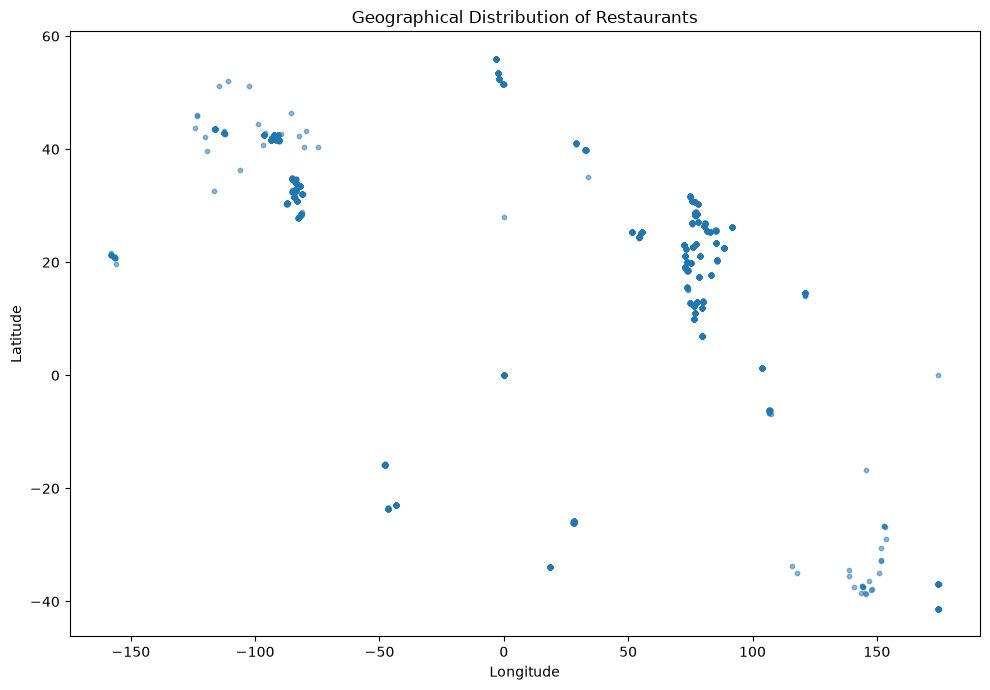

In [10]:
plt.figure(figsize=(10, 7))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.5,
    s=10
)

plt.title("Geographical Distribution of Restaurants")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.tight_layout()
plt.show()

### Analyze restaurant distribution by city

In [11]:
city_counts = df["City"].value_counts()

print("Top 10 cities by number of restaurants:")
display(city_counts.head(10))

Top 10 cities by number of restaurants:


City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

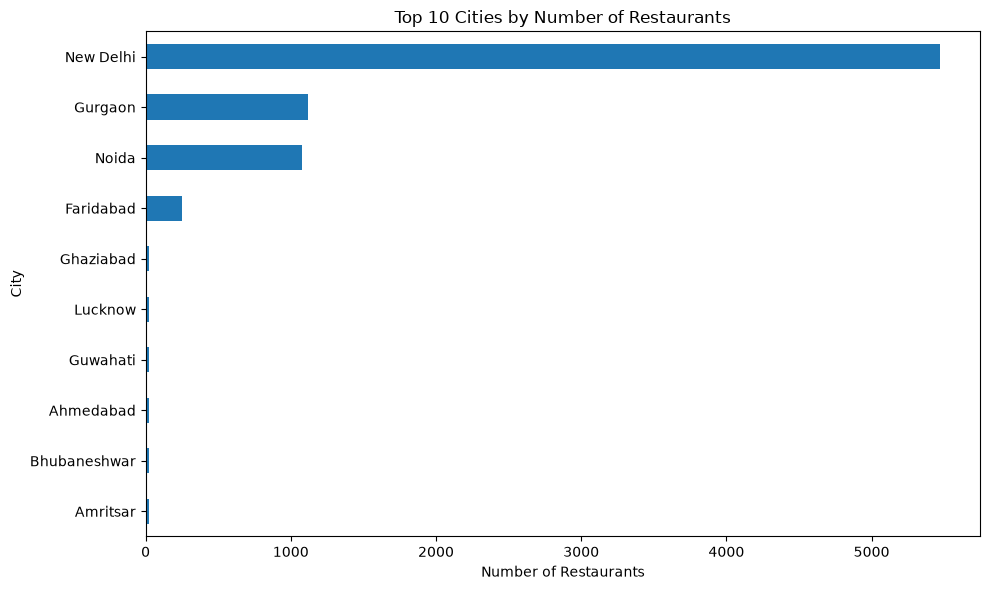

In [14]:
plt.figure(figsize=(10, 6))

city_counts.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.tight_layout()
plt.show()

### Identify the most represented city

In [15]:
top_city = city_counts.idxmax()
top_city_count = city_counts.max()

print("Most represented city:", top_city)
print("Number of restaurants:", top_city_count)

Most represented city: New Delhi
Number of restaurants: 5473


### Analyze restaurant distribution by Country Code

In [17]:
country_counts = df["Country Code"].value_counts()

print("Restaurant count by Country Code:")
print(country_counts)

Restaurant count by Country Code:
Country Code
1      8652
216     434
215      80
30       60
214      60
189      60
148      40
208      34
14       24
162      22
94       21
184      20
166      20
191      20
37        4
Name: count, dtype: int64


### Create the country distribution chart

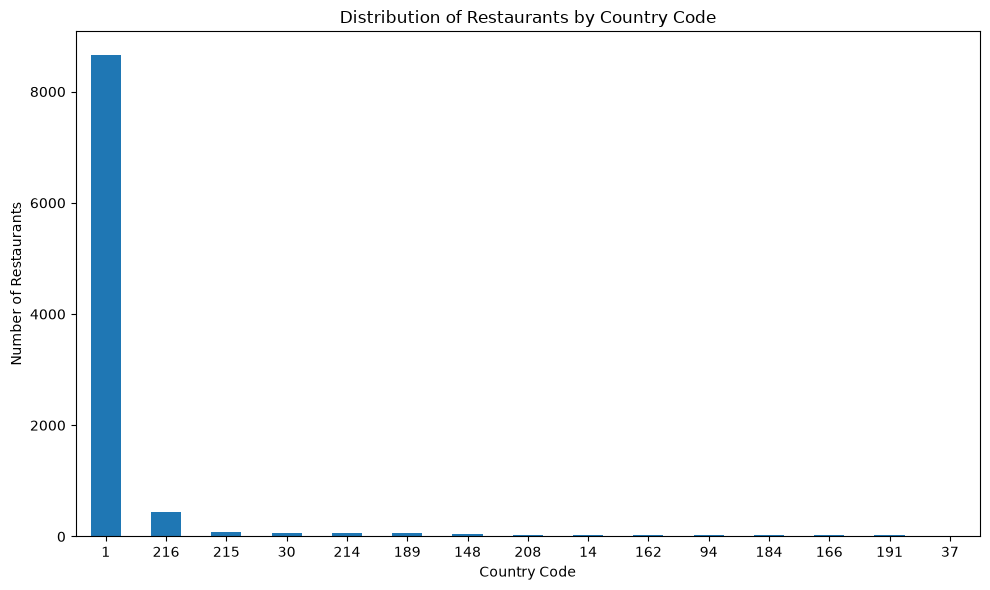

In [18]:
plt.figure(figsize=(10, 6))

country_counts.plot(kind="bar")

plt.title("Distribution of Restaurants by Country Code")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Find the most represented country code

In [19]:
top_country_code = country_counts.idxmax()
top_country_count = country_counts.max()

print("Most represented Country Code:", top_country_code)
print("Number of restaurants:", top_country_count)

Most represented Country Code: 1
Number of restaurants: 8652


### Analyze the relationship between location and rating

In [20]:
correlation = df[
    ["Latitude", "Longitude", "Aggregate rating"]
].corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,Latitude,Longitude,Aggregate rating
Latitude,1.000000,0.043207,0.000516
Longitude,0.043207,1.000000,-0.116818
Aggregate rating,0.000516,-0.116818,1.000000


### Visualize Latitude vs Rating

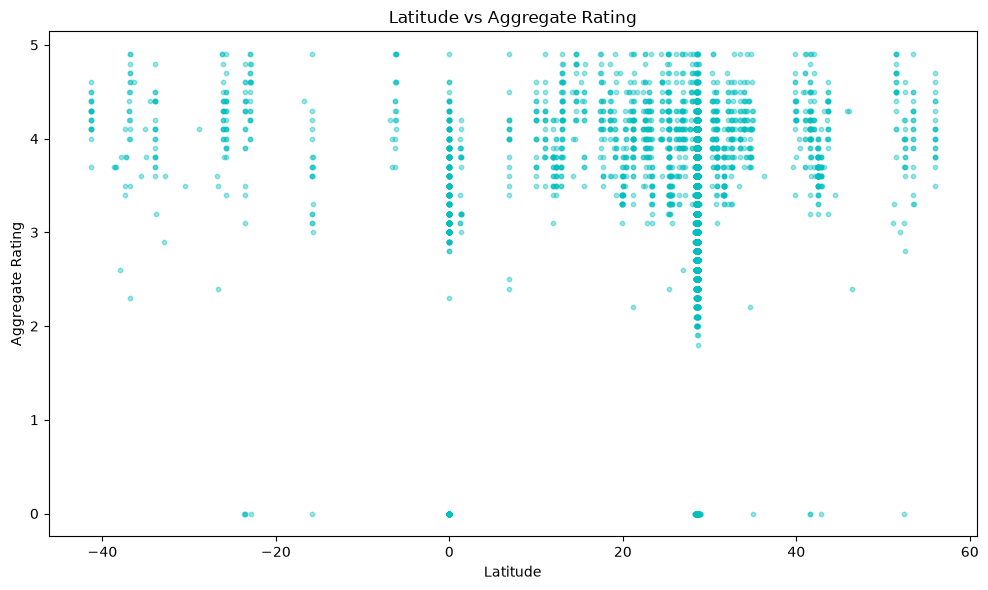

In [30]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Latitude"],
    df["Aggregate rating"],
    alpha=0.4,
    s=10,
    color="c",
)

plt.title("Latitude vs Aggregate Rating")
plt.xlabel("Latitude")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

### Visualize Longitude vs Rating

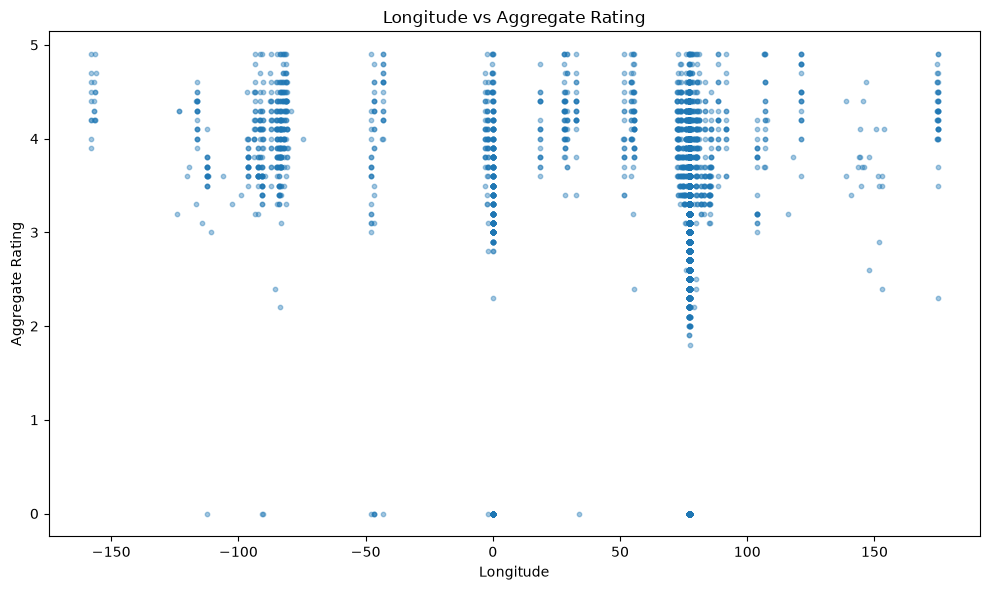

In [32]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Longitude"],
    df["Aggregate rating"],
    alpha=0.4,
    s=10
)

plt.title("Longitude vs Aggregate Rating")
plt.xlabel("Longitude")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

### Extract the correlation values

In [33]:
latitude_correlation = correlation.loc["Latitude", "Aggregate rating"]
longitude_correlation = correlation.loc["Longitude", "Aggregate rating"]

print("Latitude vs Aggregate Rating correlation:", round(latitude_correlation, 3))
print("Longitude vs Aggregate Rating correlation:", round(longitude_correlation, 3))

Latitude vs Aggregate Rating correlation: 0.001
Longitude vs Aggregate Rating correlation: -0.117


### Location and Rating Analysis - Findings

The correlation analysis was used to examine the relationship between geographical coordinates and aggregate rating.

- The correlation between Latitude and Aggregate Rating is approximately **0.001**, indicating an almost negligible linear relationship.
- The correlation between Longitude and Aggregate Rating is approximately **-0.117**, indicating a weak negative linear relationship.

Overall, the results suggest that geographical coordinates alone have a weak linear relationship with restaurant ratings. Other factors may have a stronger influence on aggregate ratings.

##### Conclusion

The geospatial analysis shows that restaurants are geographically concentrated in specific regions rather than being evenly distributed worldwide. New Delhi is the most represented city, with 5,473 restaurants, while Country Code 1 contains 8,652 restaurants.

The latitude and longitude visualizations show clear geographical clusters. The correlation analysis indicates that latitude has almost no linear relationship with aggregate rating, while longitude has a weak negative relationship.

Therefore, geographical location by itself does not appear to strongly explain restaurant ratings in this dataset. Other restaurant-related factors may contribute more significantly to rating differences.